In [1]:
# https://github.com/eddymina/ECG_Classification_Pytorch/blob/master/ECG_notebook.ipynb

import warnings
import heartbeat as hb
import normalizer
import importlib 
import random 
import time
import pandas as pd 
import numpy as np 
from collections import Counter
from scipy import signal
from scipy.signal import find_peaks, resample
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
from os import listdir
from os.path import isfile, join 
import sys
import warnings 

importlib.reload(hb)
importlib.reload(normalizer)

print('Package import complete')

Package import complete


## data arrangement

In [2]:
print('Files in Directory {}:\n'.format(os.getcwd()+'/mit_data'))
print('-------------------------------\n')
onlyfiles = [f for f in listdir(os.getcwd()+'/mit_data') if isfile(join(os.getcwd()+'/mit_data', f))]
print(sorted(onlyfiles)[1:],'\n\n***',len(onlyfiles)-1,'data files ***')   

print('\nAll patients:\n',hb.all_patients())

Files in Directory c:\Users\WonResearchGroup\Desktop\EdgeECG/mit_data:

-------------------------------

['100annotations.txt', '101.csv', '101annotations.txt', '102.csv', '102annotations.txt', '103.csv', '103annotations.txt', '104.csv', '104annotations.txt', '105.csv', '105annotations.txt', '106.csv', '106annotations.txt', '107.csv', '107annotations.txt', '108.csv', '108annotations.txt', '109.csv', '109annotations.txt', '111.csv', '111annotations.txt', '112.csv', '112annotations.txt', '113.csv', '113annotations.txt', '114.csv', '114annotations.txt', '115.csv', '115annotations.txt', '116.csv', '116annotations.txt', '117.csv', '117annotations.txt', '118.csv', '118annotations.txt', '119.csv', '119annotations.txt', '121.csv', '121annotations.txt', '122.csv', '122annotations.txt', '123.csv', '123annotations.txt', '124.csv', '124annotations.txt', '200.csv', '200annotations.txt', '201.csv', '201annotations.txt', '202.csv', '202annotations.txt', '203.csv', '203annotations.txt', '205.csv', '20

In [3]:
print("MIT Databases conditions\n")
hb.classes_further

MIT Databases conditions



{'N': 'Normal beat',
 'L': 'Left bundle branch block beat',
 'R': 'Right bundle branch block beat',
 'A': 'Atrial premature beat',
 'a': 'Aberrated atrial premature beat',
 'J': 'Nodal (junctional) premature beat',
 'S': 'Supraventricular premature beat',
 'V': 'Premature ventricular contraction',
 'F': 'Fusion of ventricular and normal beat',
 '[': 'Start of ventricular flutter/fibrillation',
 '!': 'Ventricular flutter wave',
 ']': 'End of ventricular flutter/fibrillation',
 'e': 'Atrial escape beat',
 'j': 'Nodal (junctional) escape beat',
 'E': 'Ventricular escape beat',
 '/': 'Paced beat',
 'f': 'Fusion of paced and normal beat',
 'x': 'Non-conducted P-wave (blocked APB)',
 'Q': 'Unclassifiable beat',
 '|': 'Isolated QRS-like artifact'}

In [4]:
hb.most_common_conditions(patients=hb.all_patients(), top_k=8)

[('N', 72813),
 ('L', 8075),
 ('R', 7259),
 ('V', 7129),
 ('/', 7028),
 ('A', 2513),
 ('+', 1290),
 ('f', 982)]

In [5]:
print('Specific_classes to be examined:\n')
classes = {0:'N', 1:'L', 2:'R', 3:'V', 4:'/', 5:'A', 6:'f', 7:'F'}
print(classes, '\n')
for k, v in classes.items():
    print('Class {} condition: {}' .format(k+1, hb.classes_further[v]))

Specific_classes to be examined:

{0: 'N', 1: 'L', 2: 'R', 3: 'V', 4: '/', 5: 'A', 6: 'f', 7: 'F'} 

Class 1 condition: Normal beat
Class 2 condition: Left bundle branch block beat
Class 3 condition: Right bundle branch block beat
Class 4 condition: Premature ventricular contraction
Class 5 condition: Paced beat
Class 6 condition: Atrial premature beat
Class 7 condition: Fusion of paced and normal beat
Class 8 condition: Fusion of ventricular and normal beat


Generating_plot(s)...


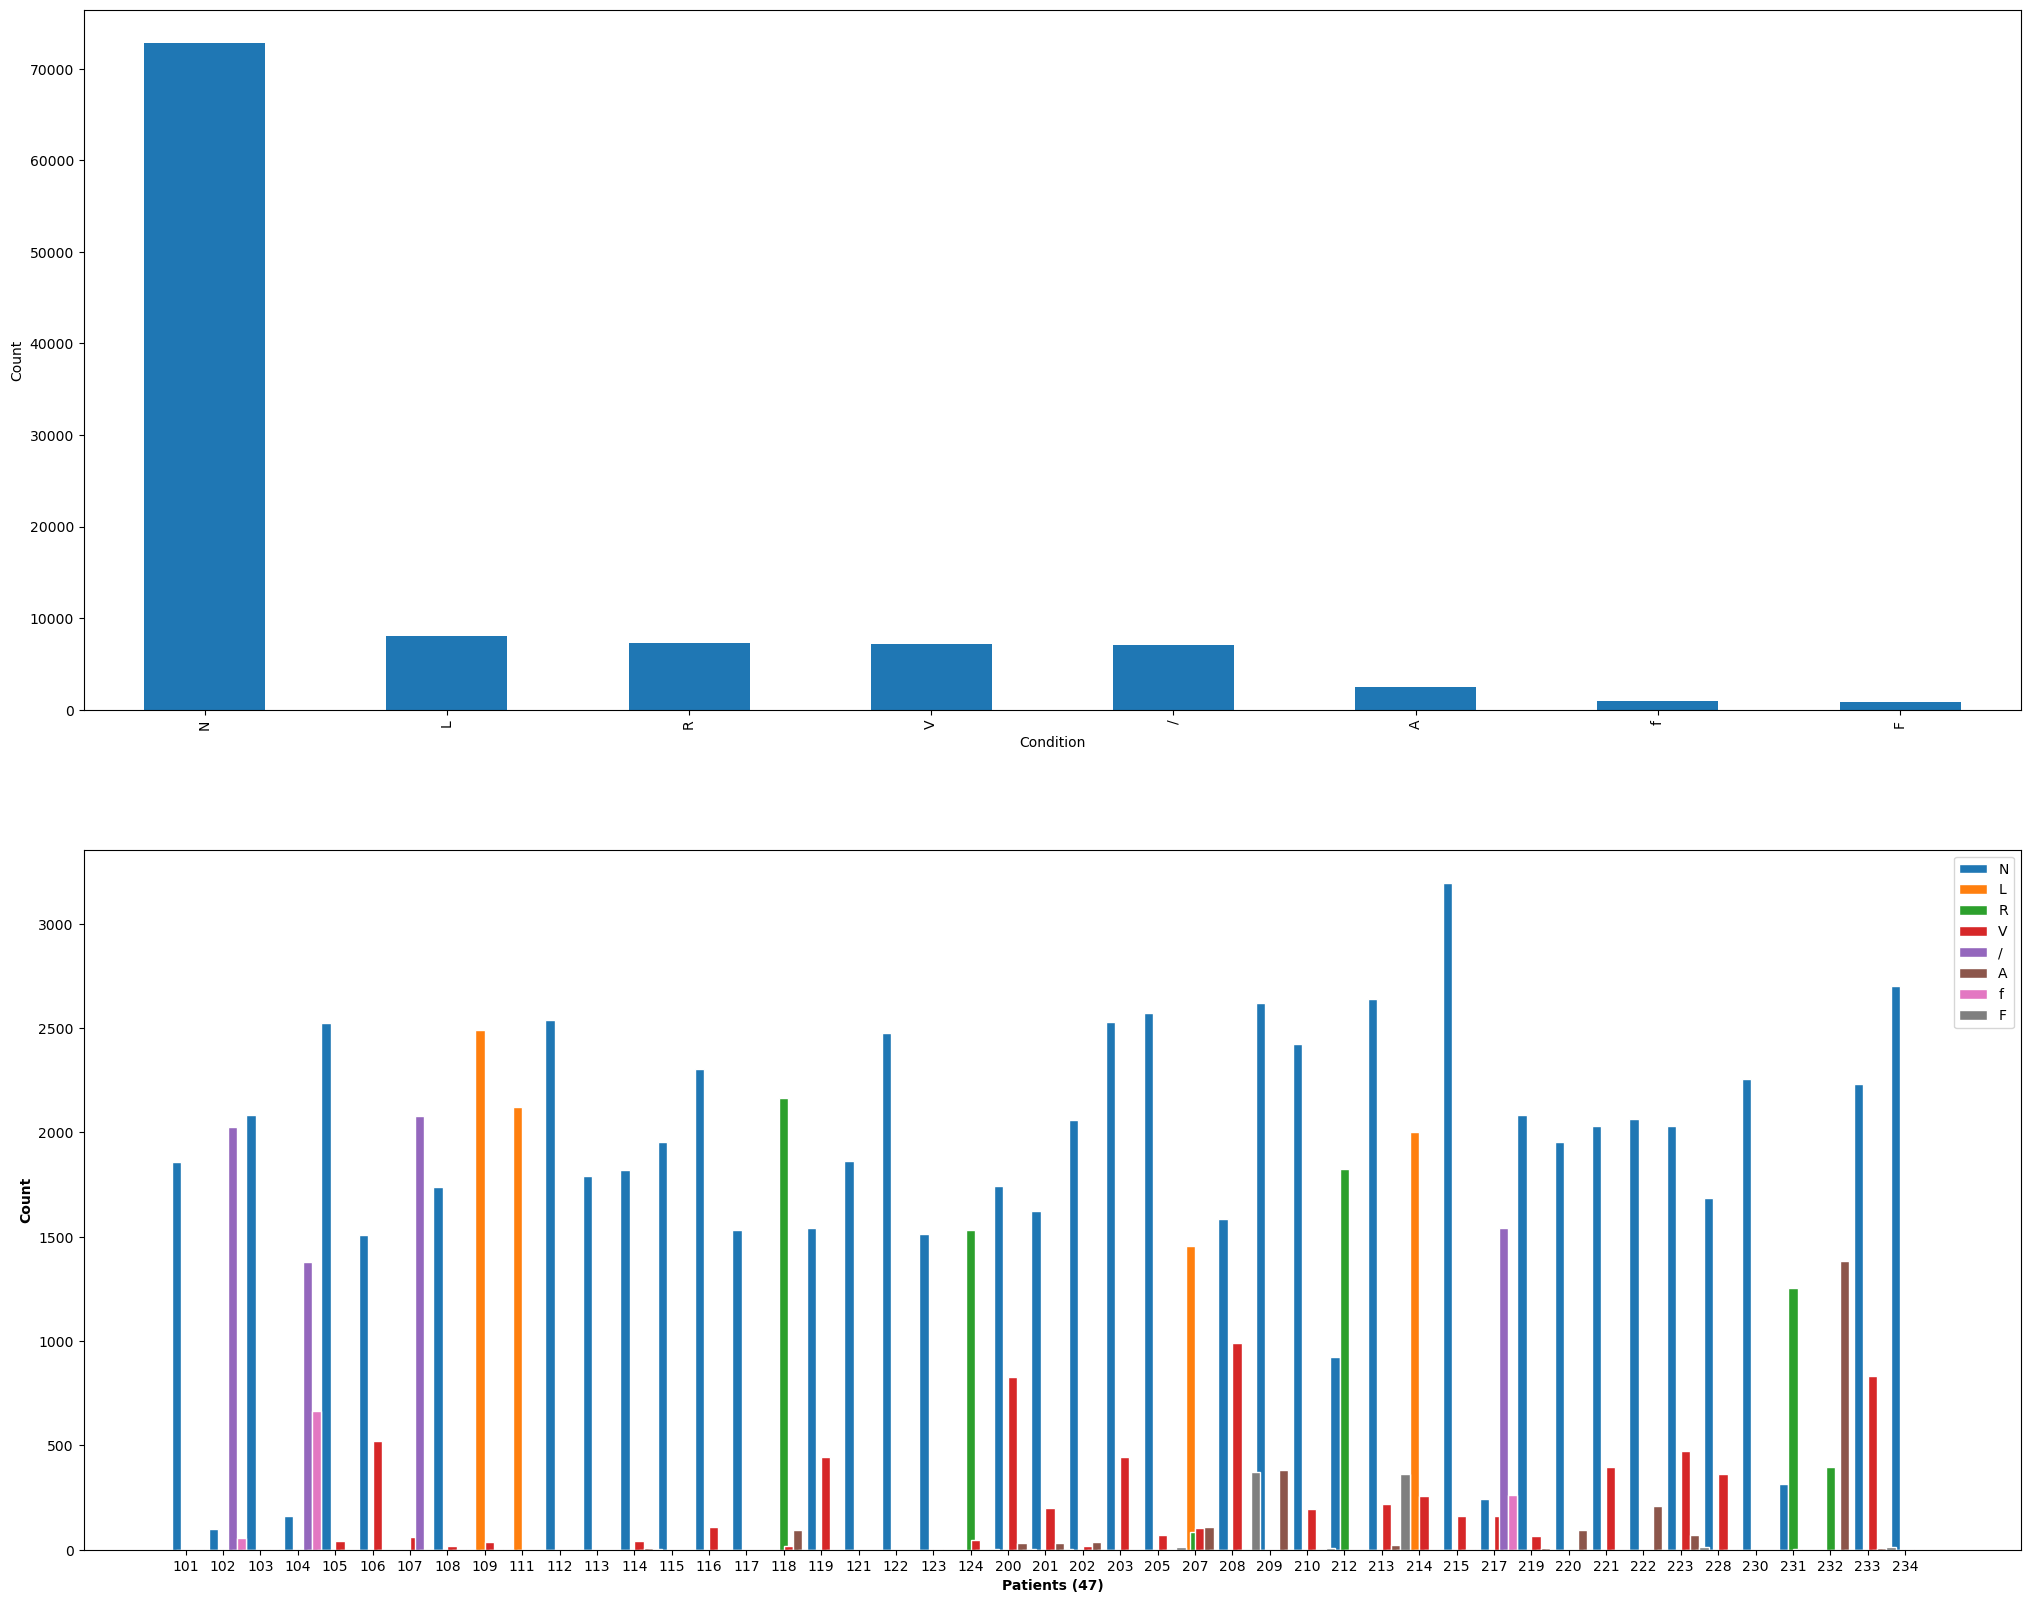

In [6]:
classes = {0:'N', 1:'L', 2:'R', 3:'V', 4:'/', 5:'A', 6:'f', 7:'F'}
patient_dic = hb.distribution_bar(patients=hb.all_patients(), classes=classes)

In [7]:
classes = {0:'N', 1:'S', 3:'F', 4:'Q'}
classes_reducer = {'N':['N', 'L', 'R', 'e', 'j'],
                   'S':['S', 'A', 'a', 'J'], 
                   'V':['V', 'E'], 
                   'F':['F'], 
                   'Q':['/', 'Q', 'f']}

for c, subclass in classes_reducer.items():
    print('For class:', c, '({})'.format(hb.classes_further[c]))
    for i in subclass:
        print("  ({})" .format(i), hb.classes_further[i])

For class: N (Normal beat)
  (N) Normal beat
  (L) Left bundle branch block beat
  (R) Right bundle branch block beat
  (e) Atrial escape beat
  (j) Nodal (junctional) escape beat
For class: S (Supraventricular premature beat)
  (S) Supraventricular premature beat
  (A) Atrial premature beat
  (a) Aberrated atrial premature beat
  (J) Nodal (junctional) premature beat
For class: V (Premature ventricular contraction)
  (V) Premature ventricular contraction
  (E) Ventricular escape beat
For class: F (Fusion of ventricular and normal beat)
  (F) Fusion of ventricular and normal beat
For class: Q (Unclassifiable beat)
  (/) Paced beat
  (Q) Unclassifiable beat
  (f) Fusion of paced and normal beat


Generating_plot(s)...


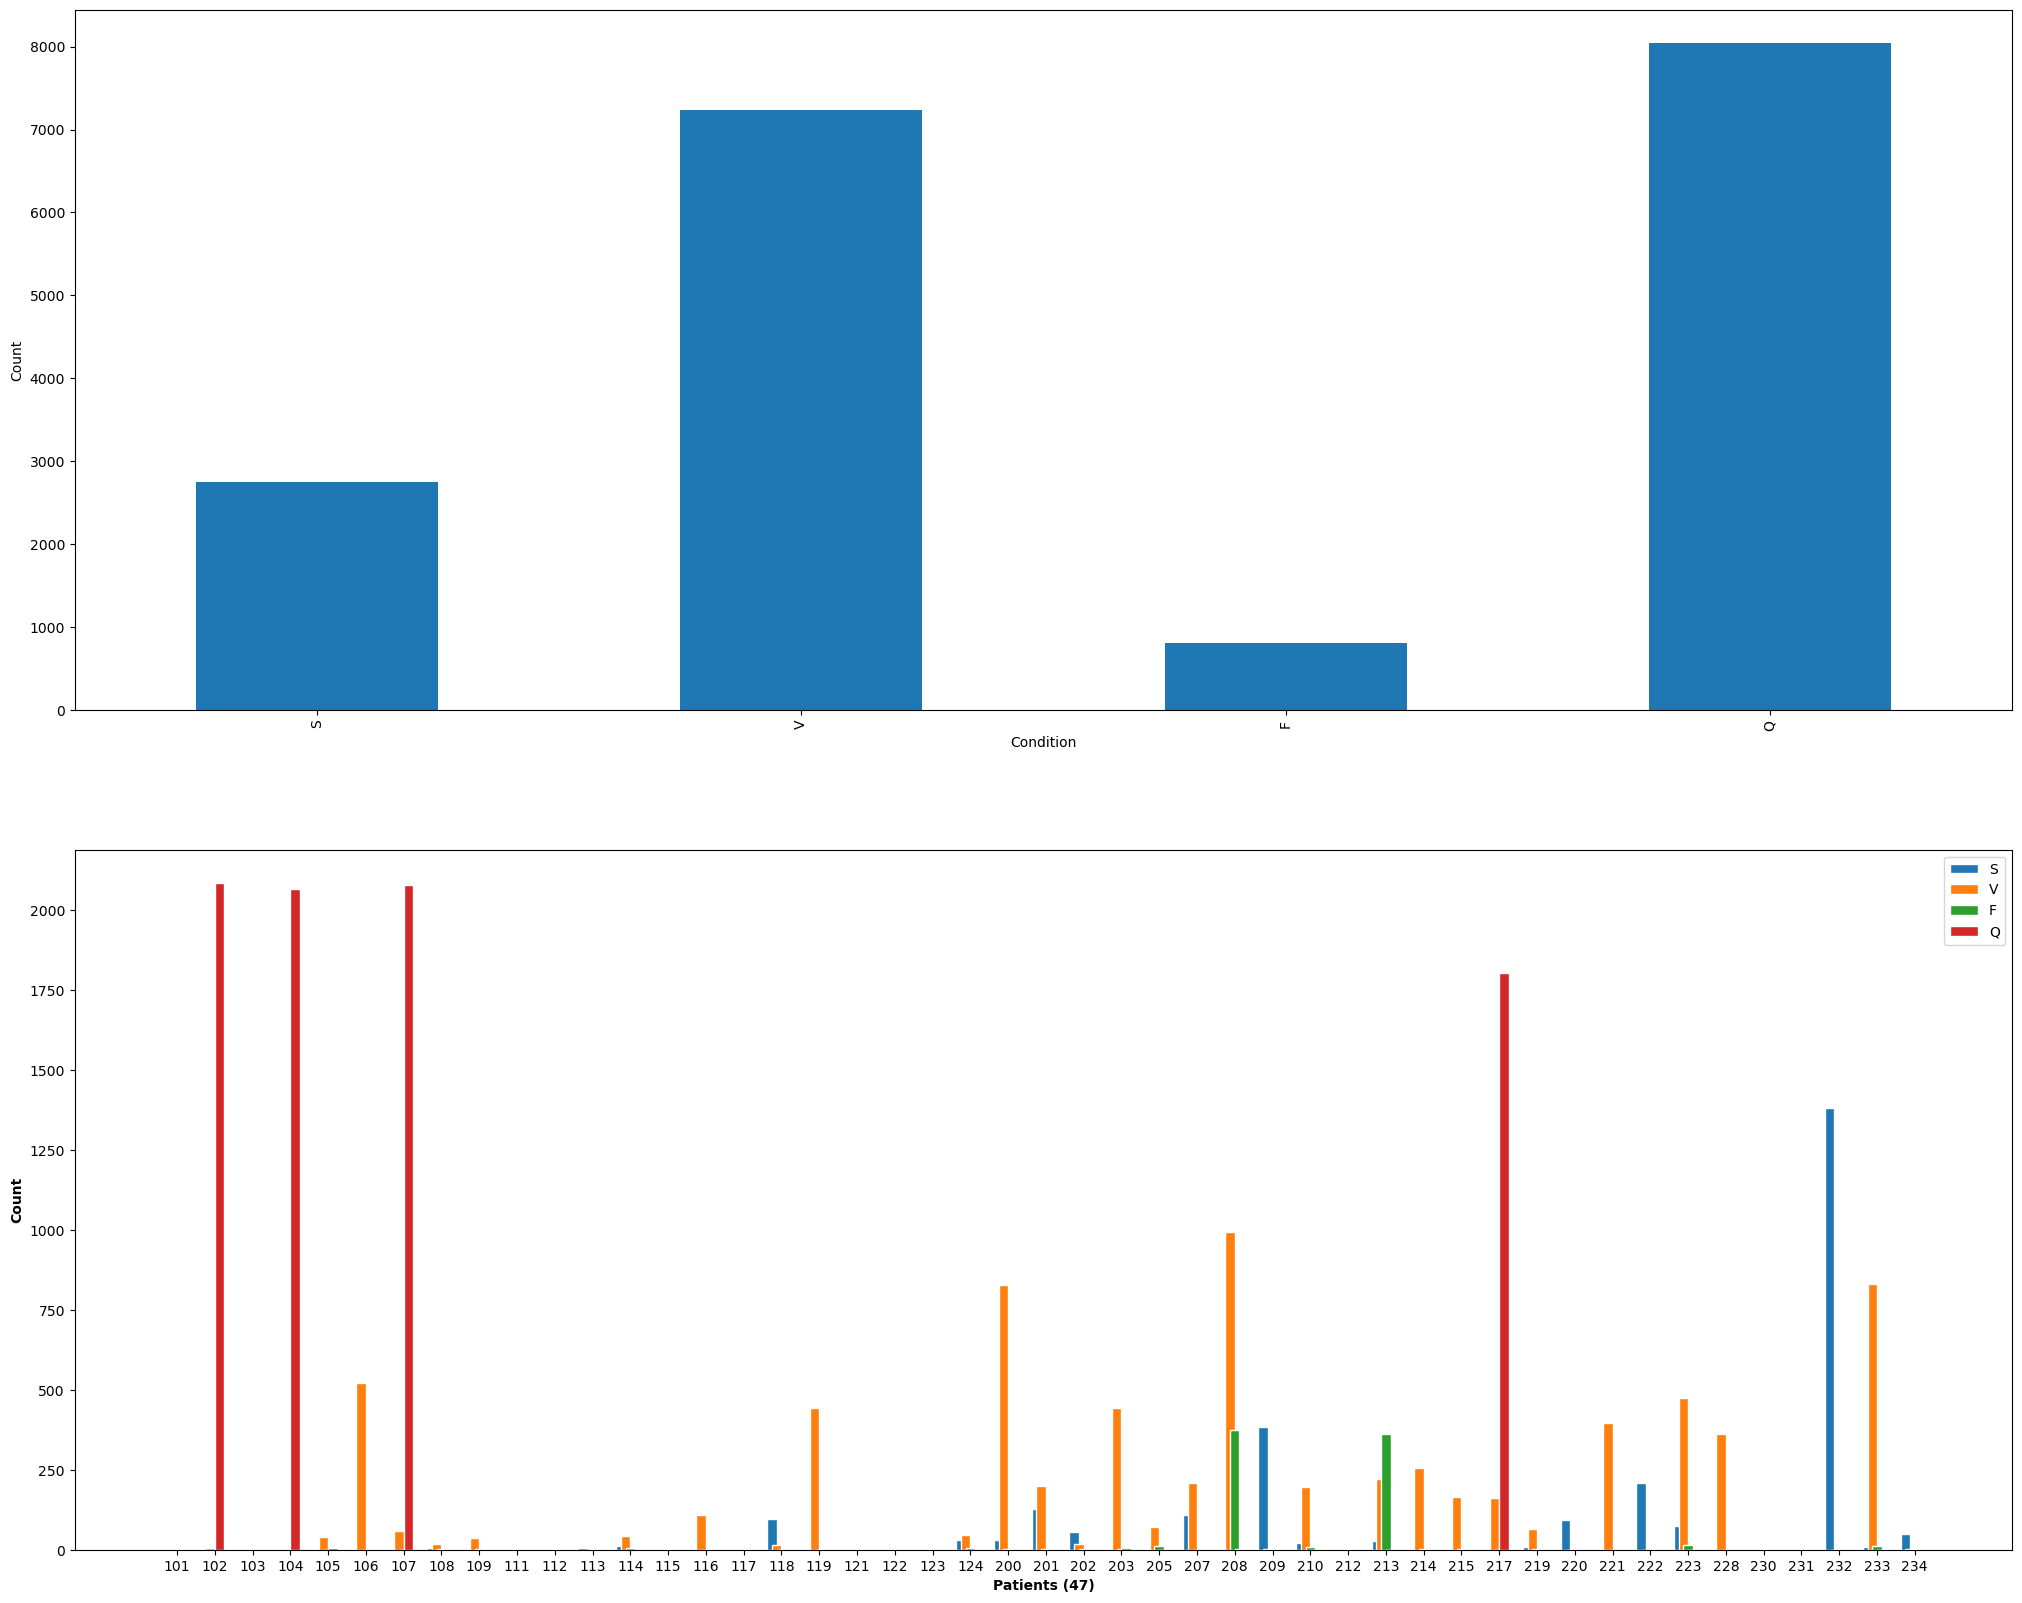

In [8]:
classes_wo_N = {0:'S', 1:'V', 2:'F', 3:'Q'}
patient_dic = hb.distribution_bar(patients=hb.all_patients(), classes=classes_wo_N,
                                  classes_reducer=classes_reducer)

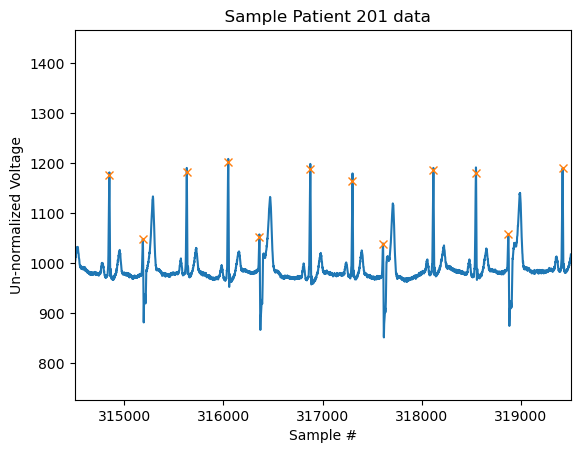

In [9]:
# This cell shoule run multiple times to check each output
patient = random.choice(hb.all_patients())
hb.get_patient_data(patient, norm=False, sample_plot=True)
plt.ylabel('Un-normalized Voltage')
plt.xlabel('Sample #')
plt.draw()

In [10]:
signal, ecg_notes = hb.get_patient_data(patient=101, norm=False, sample_plot=False)
from IPython.display import display_html
def display_side_by_side(*args):
    html_str=''
    for df in args:
        html_str += df.to_html()
    display_html(html_str.replace('table', 'table style="display:inline"'), raw=True)
print("Labeled Heart Beats | Signal Data")
display_side_by_side(ecg_notes.head(), signal.to_frame().head())

Labeled Heart Beats | Signal Data


sample_num 
 type 
 aux 
 
 
 
 
 0 
 7 
 + 
 (N 
 
 
 1 
 83 
 N 
 NaN 
 
 
 2 
 396 
 N 
 NaN 
 
 
 3 
 711 
 N 
 NaN 
 
 
 4 
 1032 
 N 
 NaN 
 
 
 
 
 
 
 signal 
 
 
 
 
 0 
 955 
 
 
 1 
 955 
 
 
 2 
 955 
 
 
 3 
 955 
 
 
 4 
 955

## normalization

Patient: 106

Norm 1: Creates a mean of 0, and a std of 1
Norm 2: Creates a mean of 0, and y range from [-1 1]
Norm 3: Creates a y range from [0 1]


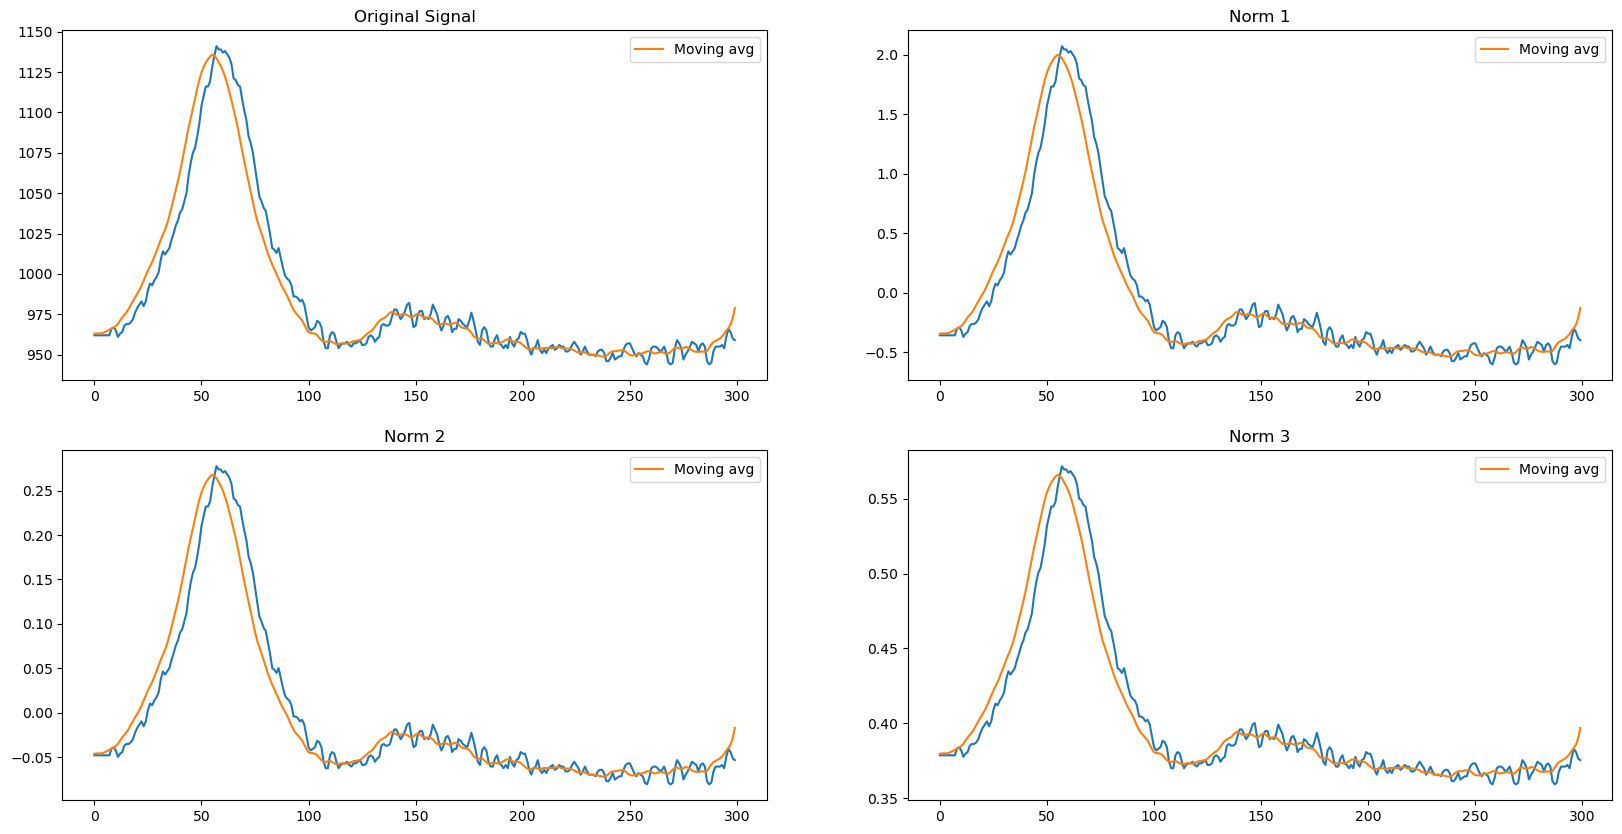

Selected Norm = 3


In [11]:
patient = random.choice(hb.all_patients())
import numpy as np 
import matplotlib.pyplot as plt 
def compare(patient, length, window=10):
    print("Patient: {}\n" .format(patient))
    sig, notes = hb.get_patient_data(patient, norm=False)
    m = hb.moving_average(sig, 10)
    n = np.random.choice(10 * length) 
    plt.figure(figsize=(20,10))

    plt.subplot(221)
    plt.plot(sig[0:length])
    plt.plot(m[0:length], label='Moving avg')
    plt.legend()
    plt.title('Original Signal')

    print('Norm 1: Creates a mean of 0, and a std of 1')
    plt.subplot(222)
    plt.plot(normalizer.z_norm_b(sig)[0:length])
    m=hb.moving_average(normalizer.z_norm_b(sig), window)
    plt.plot(m[0:length], label='Moving avg')
    plt.legend()
    plt.title('Norm 1')
    
    print("Norm 2: Creates a mean of 0, and y range from [-1 1]")
    plt.subplot(223)
    plt.plot(normalizer.z_norm2(sig)[0:length])
    m=hb.moving_average(normalizer.z_norm2(sig), window)
    plt.plot(m[0:length], label='Moving avg')
    plt.legend()
    plt.title('Norm 2')
    
    print("Norm 3: Creates a y range from [0 1]")
    plt.subplot(224)
    plt.plot(normalizer.z_norm(sig)[0:length])
    m=hb.moving_average(normalizer.z_norm(sig), window)
    plt.plot(m[0:length], label = 'Moving avg')
    plt.legend()
    plt.title('Norm 3')
    plt.show()

compare(patient=patient, length=300)
print('Selected Norm = 3')

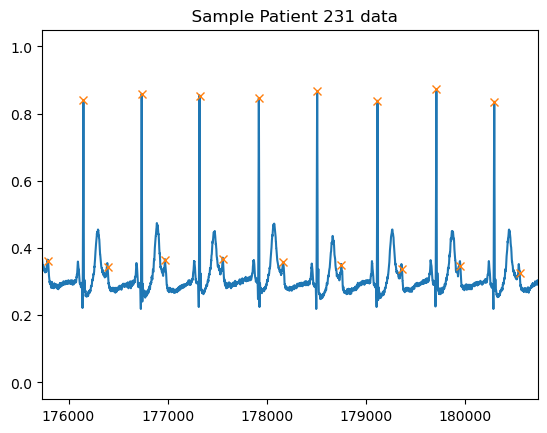

In [12]:
hb.get_patient_data(patient=231, norm=True, sample_plot=True)

## frequency relevance and heart beat isolation

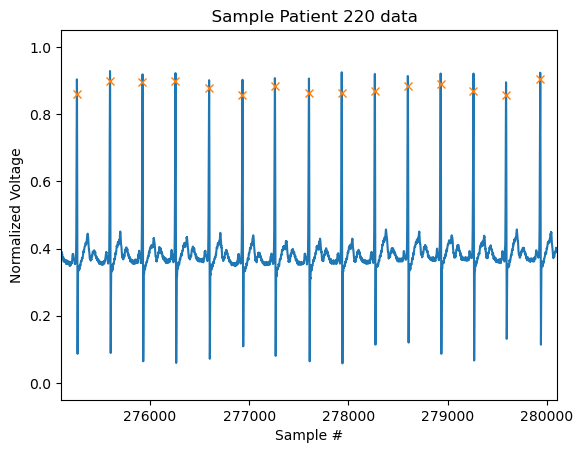

In [36]:
patient = random.choice(hb.all_patients())
hb.get_patient_data(patient, norm=True, sample_plot=True)
plt.ylabel('Normalized Voltage')
plt.xlabel('Sample #')
plt.draw()

Examining 47 patients...
Percent: [>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>] 100.00% Done...

Padding...


Average HR Sample Len: 286.26 samples (0.80s per beat)
Average HR: 80.24 bpm
Plotting...



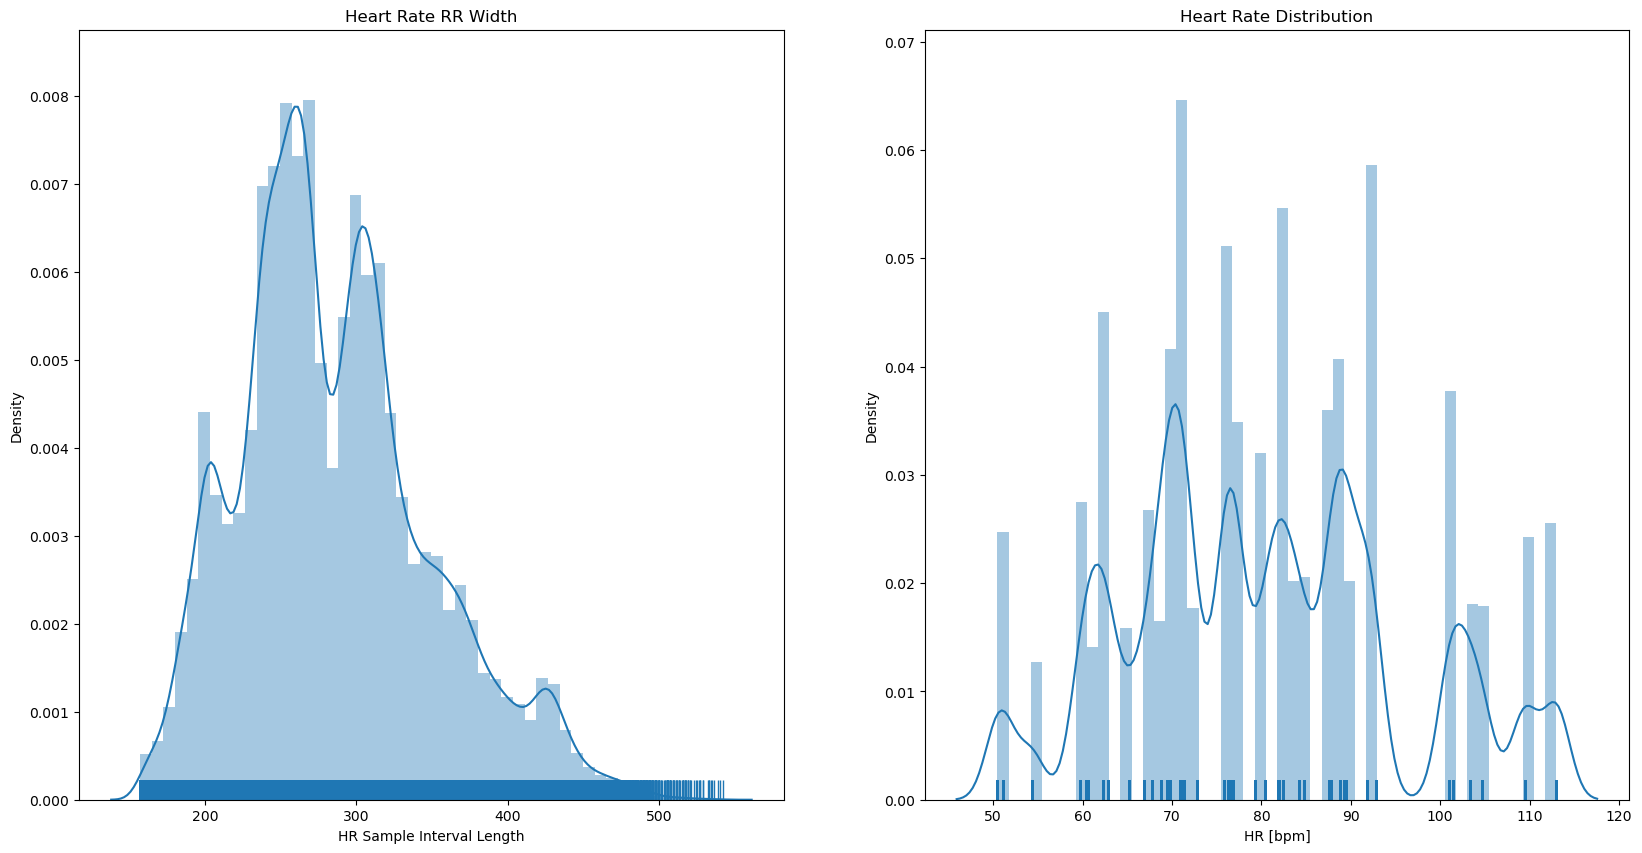

Data Loaded | Shape:(98628, 542)

    87458 cases of Normal beat

    2355 cases of Supraventricular premature beat

    8028 cases of Unclassifiable beat

    787 cases of Fusion of ventricular and normal beat

2.37min Runtime


In [44]:
X, y, isolated_beat = hb.isolate_patient_data(patients=hb.all_patients(), classes=classes,
                                              classes_further=hb.classes_further, classes_reducer=classes_reducer,
                                              min_HR=40, max_HR=140, fs=360, verbose=False, plot_figs=True)

In [45]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("sample y vals:: [patient#, HR, Condition Class]:", y[0])

X shape: (98628, 539)
y shape: (98628, 3)
sample y vals:: [patient#, HR, Condition Class]: ['101' '62.265753896919406' 'N']


MAX HB TIME: 1.4972222222222222


KeyError: 2

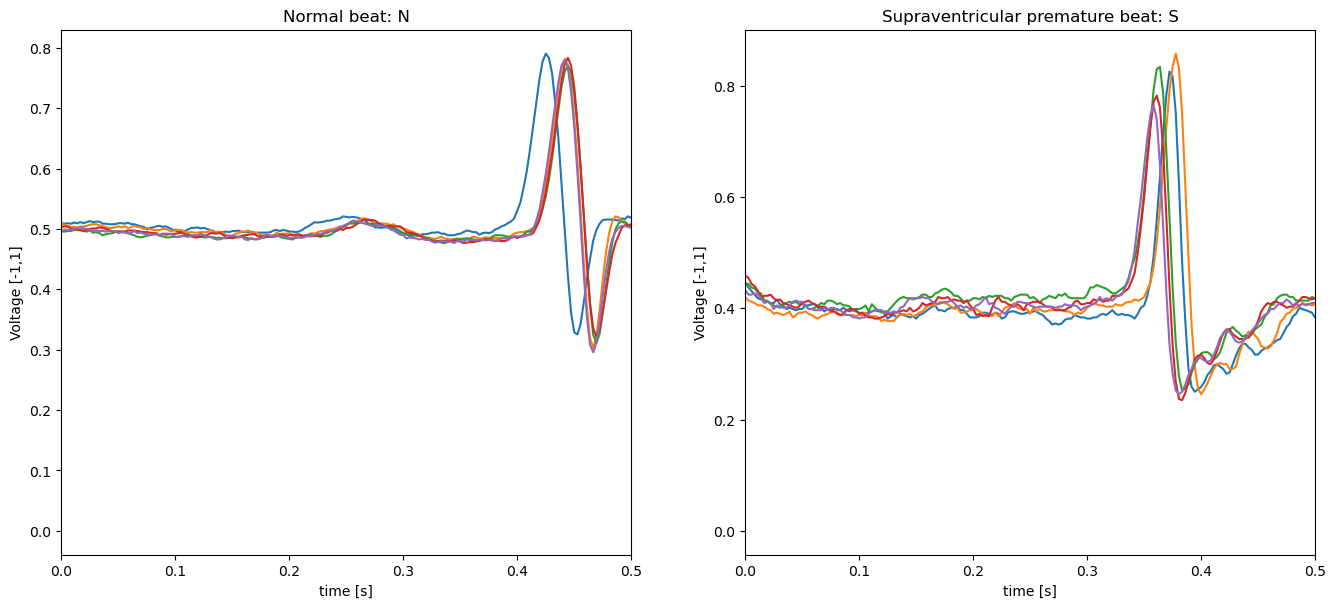

In [48]:
hb.show_sample_plots(X=X, y=y, classes=classes, classes_further=hb.classes_further, plot_xlim=1, dims=[2,3])